In [1]:
from Tools import myplot, mytimer
import time
import pandas as pd
import numpy as np
import os
import cv2
import json
from IPython.display import clear_output
from scipy.ndimage import map_coordinates, uniform_filter, sobel
from skimage.util import view_as_windows
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pickle
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
# from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV3Small
# from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Conv2D, GlobalMaxPool2D, Concatenate, BatchNormalization
# from tensorflow.keras.models import Model
# from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tracemalloc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib

In [2]:
print("TF =", tf.__version__)
print("Keras =", tf.keras.__version__)

TF = 2.21.0
Keras = 3.13.2


#### Inisialisasi

In [3]:
with open('settings.json', 'r') as f:
    dict_settings = json.load(f)

print(json.dumps(dict_settings, indent=4))

{
    "PATH_FOLDER": {
        "dataset": "Dataset",
        "dataset_pre": "Dataset_Preprocessing",
        "dataset_extract_a": "Dataset_Extract_A",
        "dataset_extract_b": "Dataset_Extract_B",
        "dataset_extract_d": "Dataset_Extract_D",
        "dataset_plot": "Plot_Dataset",
        "dataset_extract_a_plot": "Plot_Dataset_Extract_A",
        "dataset_extract_b_plot": "Plot_Dataset_Extract_B",
        "dataset_extract_d_plot": "Plot_Dataset_Extract_D",
        "path_model_plot": "Plot_Evaluasi",
        "path_plot": "Plot",
        "path_excel": "Excel",
        "path_model_a": "Model_A",
        "path_model_b": "Model_B",
        "path_model_c": "Model_C",
        "path_model_d": "Model_D"
    },
    "PATH_FILE": {
        "dataset": "Excel\\dataset.xlsx",
        "dataset_extract_a": "Excel\\dataset_extract_A.xlsx",
        "dataset_extract_b": "Excel\\dataset_extract_B.xlsx",
        "dataset_selected_c": "Excel\\dataset_selected_C.xlsx",
        "dataset_extract_d": "

In [4]:
PATH_FOLDER = dict_settings['PATH_FOLDER']
PATH_FILE = dict_settings['PATH_FILE']
IMAGE_SIZE = dict_settings['IMAGE_SIZE']
DEFAULT_EXTENSION = dict_settings['DEFAULT_EXTENSION']
DEFAULT_EXTENSION_PLOT = dict_settings['DEFAULT_EXTENSION_PLOT']

# 1. DATASET
___

In [5]:
df = pd.read_excel(PATH_FILE['dataset'])
df

,LOKASI_GAMBAR,SUMBER_DATASET,LABEL
0,dataset_1\0\ef5155990874.png,dataset_1,0
1,dataset_1\0\0a85a1e8f9e9.png,dataset_1,0
2,dataset_1\0\6a2642131e4a.png,dataset_1,0
3,dataset_1\0\8a8a251770cd.png,dataset_1,0
4,dataset_1\0\ac1667fac512.png,dataset_1,0
...,...,...,...
735,dataset_1\1\cfd1bd0fcbb4.png,dataset_1,1
736,dataset_1\1\f72ef9ceeaa8.png,dataset_1,1
737,dataset_1\1\ca63fe4f4b52.png,dataset_1,1
738,dataset_1\1\4aa07d720638.png,dataset_1,1


# 2. EKSTRAKSI FITUR
___

In [ ]:
# =====================================================================
# 1. Bilinear Interpolation Sampling
# =====================================================================
def bilinear_interpolate_full(image, x, y):
    return map_coordinates(image, [[y], [x]], order=1, mode='reflect')[0]

# =====================================================================
# 2. Noise-Aware Thresholding
# =====================================================================
def compute_noise_threshold_map(img, size=3, k=0.5):
    mu = uniform_filter(img, size=size, mode='reflect')
    mu2 = uniform_filter(img * img, size=size, mode='reflect')
    sigma = np.sqrt(np.maximum(mu2 - mu * mu, 0))
    # return mu + k * sigma
    return mu - k * sigma   # MA lebih gelap dari background

# =====================================================================
# 3. Graph Connectivity Weighting
# =====================================================================
def get_graph_neighbors(P, R):
    angles = np.linspace(0, 2*np.pi, P, endpoint=False)
    coords = [(R*np.cos(a), R*np.sin(a)) for a in angles]
    return coords

def adaptive_normalize(img, eps=1e-8):
    img = img.astype(np.float32)
    vmin, vmax = img.min(), img.max()

    # Normalisasi hanya jika belum pada rentang stabil
    if vmax > 1.0 + eps:
        img = (img - vmin) / (vmax - vmin + eps)


    return img

# Jarak
def distance_weight(dx, dy):
    d = np.sqrt(dx**2 + dy**2)
    return 1.0 / (d + 1e-8)

# Gradien Lokal
def gradient_weight(img, size=3, eps=1e-8):
    img = adaptive_normalize(img)

    gx = sobel(img, axis=1, mode='reflect')
    gy = sobel(img, axis=0, mode='reflect')

    grad_mag = np.sqrt(gx**2 + gy**2)

    # Normalisasi berbasis statistik lokal
    local_mean = uniform_filter(grad_mag, size=size)
    grad_w = grad_mag / (local_mean + eps)

    return grad_w

# Konsistensi pola MA
def consistency_weight(img, size=3, eps=1e-8):
    img = adaptive_normalize(img)

    # --------------------------------------------------
    # 2) MA consistency
    # --------------------------------------------------
    local_mean = uniform_filter(img, size=size)
    diff = np.abs(img - local_mean)

    # Normalisasi berbasis statistik lokal
    local_diff_mean = uniform_filter(diff, size=size)

    konstitusi = 1.0 / (1.0 + diff / (local_diff_mean + eps))

    return konstitusi

# =====================================================================
# 5. Graph-Based LBP Calculation
    # - Bilinear interpolation (Modifikasi 1)
    # - Noise-aware threshold (Modifikasi 2)
    # - Graph connectivity weighting (Modifikasi 3)
# =====================================================================
def graph_based_lbp(image, P=8, R=1, k_thresh=0.5, ent_win=3, n_bins=8):
    img = image.astype(np.float32)
    # NORMALISASI GLOBAL
    # img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    H, W = img.shape

    center = img
    # Meshgrid piksel
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    # Entropy Map
    entropy_map = compute_entropy_map(img, win=ent_win, n_bins=n_bins)
    # Konstitusi pola MA
    konstitusi = consistency_weight(entropy_map)
    # Modifikasi 2: Noise Aware Thresholding
    noise_aware = compute_noise_threshold_map(center, k=k_thresh)
    # Modifikasi 3: Graph Connectivity Weighting
    # Gradien Lokal
    grad = gradient_weight(img)
    # Hitung Bobot
    W = (1 + grad) * konstitusi
    W = W / (np.mean(W) + 1e-8)

    # Neighbor sampling
    neighbors = get_graph_neighbors(P, R)

    bits = []
    for i, (dx, dy) in enumerate(neighbors):
        # Modifikasi 1: Bilinear Interpolation
        intensitas = bilinear_interpolate_full(img, xx + dx, yy + dy)
        
        # Tambahkan bobot pada tetangga
        diff = intensitas - noise_aware
        bit = (diff * W >= 0).astype(np.uint8)

        bits.append(bit)

    # Encode LBP
    bits = np.stack(bits, axis=-1)

    return bits, entropy_map
# ==============================================================
# 6. Entropy Map
# ==============================================================
def compute_entropy_map(img, win=3, n_bins=8, show_mask=False):
    # Buat patch sliding window: shape (H-win+1, W-win+1, win, win)
    patches = view_as_windows(img, (win, win))
    ph, pw = patches.shape[:2]

    # Flatten 1 patch = win*win piksel
    flat = patches.reshape(-1, win * win)

    # Histogram quantization
    bins = np.linspace(img.min(), img.max() + 1e-6, n_bins + 1)
    inds = np.digitize(flat, bins) - 1

    # Hitung histogram 8 bin
    hist = np.zeros((len(flat), n_bins), dtype=np.float32)
    for b in range(n_bins):
        hist[:, b] = (inds == b).sum(axis=1)

    # Normalisasi: jumlah piksel per window = win*win
    probs = hist / (win * win)

    # Hitung entropy tiap window
    with np.errstate(divide='ignore', invalid='ignore'):
        ent = -np.sum(np.where(probs > 0, probs * np.log(probs), 0), axis=1)

    # Kembalikan ke bentuk spasial
    entropy_map = ent.reshape(ph, pw)
    # Ubah nilai kurang dari 0 menjadi 0
    entropy_map[entropy_map < 1e-8] = 0.0

    # Padding Agar ukuran Kembali
    pad = win // 2
    entropy_map = np.pad(entropy_map, pad_width=pad, mode='reflect')

    # Kandidat MA
    mask = entropy_map > (entropy_map.mean() + 0.5 * entropy_map.std())
    entropy_map = np.where(mask, entropy_map, 0.3 * entropy_map)

    if show_mask:
        return mask, entropy_map

    return entropy_map

# ==============================================================
# 7. Histogram G-LBP (UNIFORM, LBP^u2)
# ==============================================================
def remove_border(green_channel, glbp_img, R=1, P=8, method='default'):
    h, w = green_channel.shape
    mask = np.zeros((h, w), dtype=bool)

    # area dalam
    mask[R:h-R, R:w-R] = True

    # threshold adaptif
    threshold = 10
    mask &= (green_channel > threshold)

    # set background agar selalu terang
    if method == 'uniform':
        glbp_img[~mask] = P + 1
    else:
        glbp_img[~mask] = 2 ** P - 1

    return glbp_img

def glbp_histogram(green_channel, bits, R=1, P=8, method="uniform"):
    if method == 'uniform':
        # uniform LBP → P + 2 bin
        n_bins = P + 2
        # Hitung transisi circular dan jumlah ones
        transitions = np.sum(bits != np.roll(bits, 1, axis=-1), axis=-1)
        ones_count = np.sum(bits, axis=-1)
        glbp_image = np.where(transitions <= 2, ones_count, P + 1).astype(np.uint8)
    else:
        n_bins = 2**P
        powers_of_two = 2 ** np.arange(P)
        glbp_image = np.tensordot(bits, powers_of_two, axes=([2], [0])).astype(np.uint8)

    # Remove Border
    glbp_image = remove_border(
        green_channel=green_channel,
        glbp_img=glbp_image,
        R=R,
        P=P,
        method=method
    )

    # Histogram
    hist, _ = np.histogram(
        glbp_image.ravel(),
        bins=n_bins,
        range=(0, n_bins)
    )

    # Normalisasi
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-8)

    feature_names = [f"LBP_{i}" for i in range(n_bins)]
    return glbp_image, dict(zip(feature_names, hist))

# =====================================================================
# 7. Pipeline Ekstraksi Fitur GLBP (Untuk Green Channel)
# =====================================================================
def extract_glbp_features(image_input, P=8, R=1, ent_win=3, n_bins=8, method="default"):
    # Muat Gambar
    if isinstance(image_input, str):
        img = cv2.imread(image_input, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"File tidak ditemukan: {image_input}")
    else:
        img = image_input
    # Gunakan green channel (sesuai standar citra fundus)
    if img.ndim == 3:
        green_channel = img[:, :, 1]
    else:
        green_channel = img.astype(np.uint8)

    # Extract G-LBP
    bits, entropy_map = graph_based_lbp(image=green_channel, P=P, R=R, ent_win=ent_win, n_bins=n_bins)
    # Histogram
    glbp_image, hist = glbp_histogram(green_channel=green_channel,
                                      bits=bits, 
                                      P=P,
                                      R=R,
                                      method=method)
    
    return {
        "glbp_image": glbp_image,
        "glbp_histogram": hist,
        "entropy_map": entropy_map
    }


## Visualisasi Hasil Ekstraksi Fitur

Label: 0


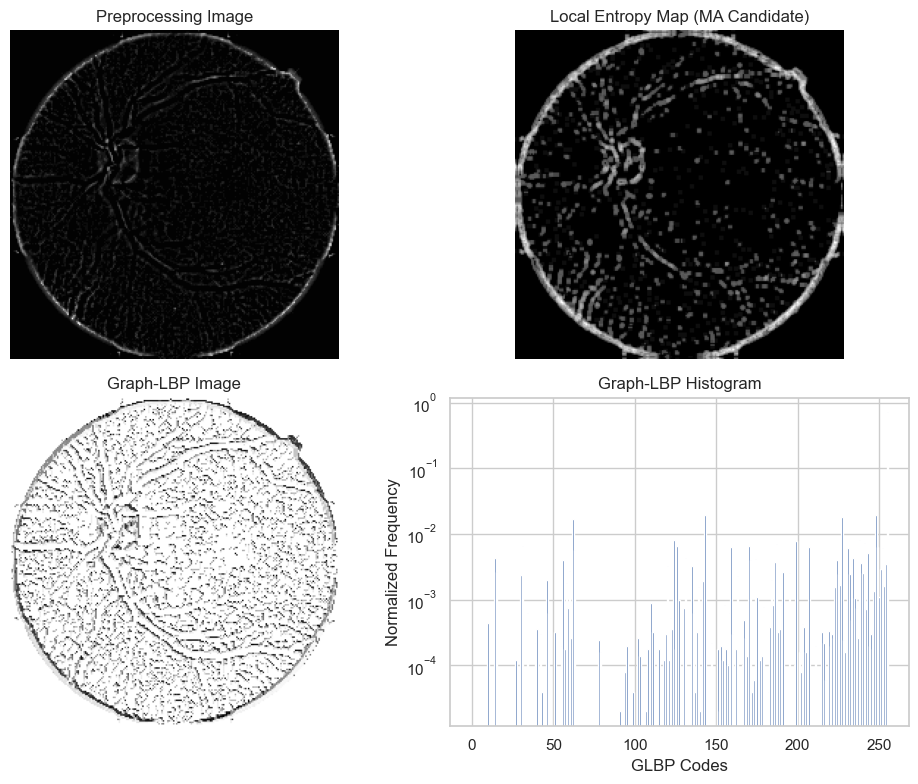

Label: 1


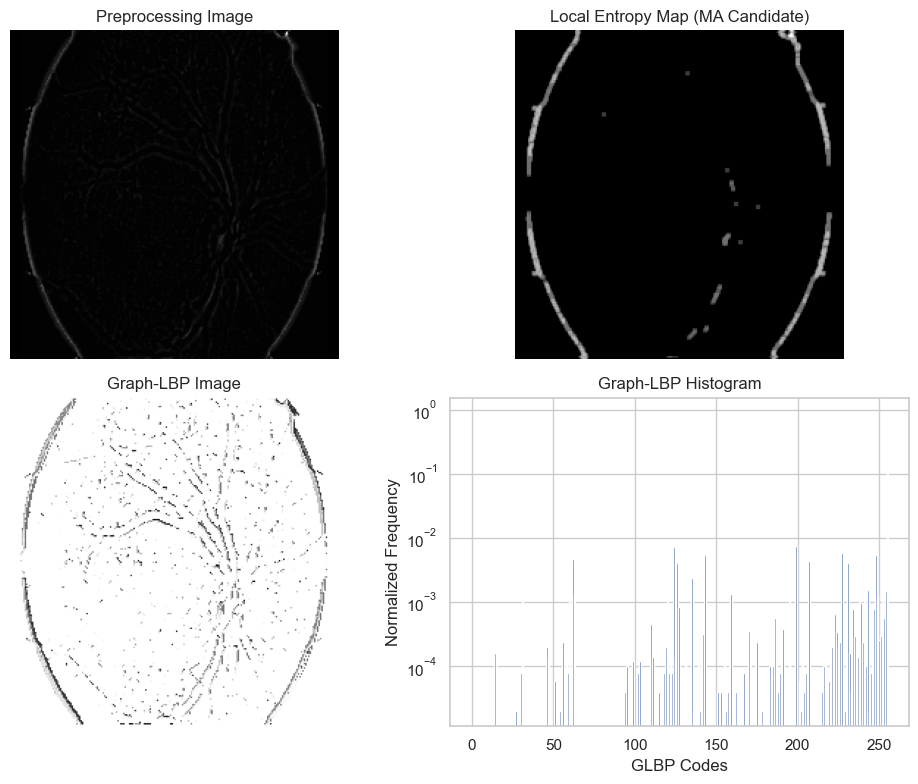

In [7]:
%matplotlib inline
iloc = 0

for label in df['LABEL'].unique():
    print(f"Label: {label}")
    example_path = df[df['LABEL'] == label].iloc[iloc]['LOKASI_GAMBAR']

    # Baca gambar
    img_pre = cv2.imread(f"{PATH_FOLDER['dataset_pre']}/{example_path}")
    img_pre = cv2.cvtColor(img_pre, cv2.IMREAD_COLOR)

    # Proses Ekstraksi GLBP
    process_extract = extract_glbp_features(image_input=img_pre)
    # Data Hasil Ekstraksi
    glbp_image = process_extract.get('glbp_image', [])
    img_entropy = process_extract.get('entropy_map', [])
    glbp_features = process_extract.get('glbp_histogram', [])  # dict fitur histogram

    # Ambil histogram
    hist_values = list(glbp_features.values())
    hist_labels = list(glbp_features.keys())

    # Tampilkan Plot
    myplot.plot_glbp_example(
        img_pre=img_pre,
        img_entropy=img_entropy,
        glbp_image=glbp_image,
        hist_values=hist_values
    )

In [8]:
process_extract

{'glbp_image': array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], shape=(224, 224), dtype=uint8),
 'glbp_histogram': {'LBP_0': np.float32(0.0),
  'LBP_1': np.float32(0.0),
  'LBP_2': np.float32(0.0),
  'LBP_3': np.float32(0.0),
  'LBP_4': np.float32(0.0),
  'LBP_5': np.float32(0.0),
  'LBP_6': np.float32(0.0),
  'LBP_7': np.float32(0.0),
  'LBP_8': np.float32(0.0),
  'LBP_9': np.float32(0.0),
  'LBP_10': np.float32(0.0),
  'LBP_11': np.float32(0.0),
  'LBP_12': np.float32(0.0),
  'LBP_13': np.float32(0.0),
  'LBP_14': np.float32(0.00015943877),
  'LBP_15': np.float32(0.00017936862),
  'LBP_16': np.float32(0.0),
  'LBP_17': np.float32(0.0),
  'LBP_18': np.float32(0.0),
  'LBP_19': np.float32(0.0),
  'LBP_20': np.float32(0.0),
  'LBP_21': np.float32(0.0),
  'L

## Proses Ekstraksi Fitur

In [ ]:
matplotlib.use('Agg')

# Mulai timer
timer = mytimer.loop_timer()
next(timer)

total_iterasi = len(df)
time_list = []

dict_extract_features = {}
for i, (index, item) in enumerate(df.iterrows()):
    clear_output(wait=True)  # Progress lebih bersih

    # =================================================
    # 1. Path lokasi gambar
    # =================================================
    path_file = item['LOKASI_GAMBAR']
    filename, ext = os.path.splitext(path_file)

    path_img_pre = os.path.join(PATH_FOLDER['dataset_pre'], f"{filename}{DEFAULT_EXTENSION}") # Lokasi Gambar Preprocessing
    path_glbp_img = os.path.join(PATH_FOLDER['dataset_extract_b'], f"{filename}{DEFAULT_EXTENSION}") # Lokasi Gambar Ekstraksi GLBP
    path_entropy_npy = os.path.join(PATH_FOLDER['dataset_extract_b'], f"{filename}_entropy.npy") # Lokasi Entropy GLBP
    path_plot = os.path.join(PATH_FOLDER['dataset_extract_b_plot'], f"{filename}_plot{DEFAULT_EXTENSION_PLOT}") # Lokasi Plot

    # =================================================
    # 2. Ekstraksi GLBP
    # =================================================
    img_pre = cv2.imread(path_img_pre, cv2.IMREAD_COLOR)
    result = extract_glbp_features(image_input=img_pre)

    # Ambil hasil ekstraksi
    glbp_img = result.get("glbp_image")
    glbp_hist = result.get("glbp_histogram")
    glbp_entropy = result.get("entropy_map")
    label = item['LABEL']
    hist_values = list(glbp_hist.values())
    
    # =================================================
    # Simpan Gambar
    # =================================================
    # Hapus gambar sebelumnya
    if os.path.exists(path_glbp_img):
        os.remove(path_glbp_img)
    if os.path.exists(path_entropy_npy):
        os.remove(path_entropy_npy)
        
    # GLBP
    rgb_glbp = cv2.merge([glbp_img, glbp_img, glbp_img])
    cv2.imwrite(path_glbp_img, rgb_glbp)
    # Entropy Map
    np.save(path_entropy_npy, glbp_entropy)

    # =================================================
    # 4. Simpan fitur histogram (untuk DataFrame)
    # =================================================
    dict_extract_features[index] = {
        **glbp_hist,
        "LABEL": label
    }

    # =============================================================================
    # Simpan Plot
    # =============================================================================
    myplot.plot_glbp_example(
        img_pre=img_pre,
        img_entropy=glbp_entropy,
        glbp_image=glbp_img,
        hist_values=hist_values,
        save_as=path_plot,
        show=False
    )

    # =================================================
    # Hitung waktu iterasi
    # =================================================
    dt = timer.send("tick")
    if dt is not None:
        time_list.append(dt)

    print(f"Proses Ekstraksi GLBP... {i + 1}/{total_iterasi}")
    print(f"Waktu iterasi ini: {mytimer.format_time(dt)}")


# =====================================================
# Akhiri timer dan hitung rata-rata waktu
# =====================================================
info = timer.send("done")
info["avg_time"] = sum(time_list) / len(time_list)

# =====================================================
# Tampilkan Ringkasan
# =====================================================
print("\n======================")
print("       RINGKASAN     ")
print("======================")
print(f"Total iterasi            : {total_iterasi}")
print(f"Total waktu              : {mytimer.format_time(info['total_time'])}")
print(f"Rata-rata waktu/iterasi  : {mytimer.format_time(info['avg_time'])}")

Proses Ekstraksi GLBP... 740/740
Waktu iterasi ini: 0 detik

       RINGKASAN     
Total iterasi            : 740
Total waktu              : 1 menit 46 detik
Rata-rata waktu/iterasi  : 0 detik


In [10]:
# Mengubah menjadi dataframe
df_features = pd.DataFrame.from_dict(dict_extract_features, orient='index')
# Simpan dataset ekstrasi
df_features.to_excel(PATH_FILE['dataset_extract_b'], index=None)
df_features

,LBP_0,LBP_1,LBP_2,LBP_3,LBP_4,LBP_5,LBP_6,LBP_7,LBP_8,LBP_9,...,LBP_247,LBP_248,LBP_249,LBP_250,LBP_251,LBP_252,LBP_253,LBP_254,LBP_255,LABEL
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001375,0.019372,0.006278,0.001116,0.002950,0.006218,0.001634,0.003508,0.707709,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002292,0.019093,0.007095,0.000897,0.002212,0.009148,0.002571,0.003707,0.679727,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001156,0.014768,0.003388,0.000797,0.002113,0.004245,0.001076,0.001834,0.771265,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000757,0.011420,0.003966,0.000877,0.001993,0.004225,0.000618,0.001933,0.848792,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001933,0.020986,0.008331,0.000817,0.003408,0.008211,0.002033,0.002830,0.671257,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000717,0.004564,0.002013,0.000040,0.000379,0.004185,0.000717,0.000618,0.923071,1
736,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001156,0.006756,0.002392,0.000438,0.001276,0.004664,0.001036,0.001913,0.881936,1
737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000737,0.006896,0.001634,0.000737,0.001056,0.004624,0.000717,0.001535,0.886101,1
738,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001714,0.007952,0.002511,0.000359,0.000498,0.006158,0.001475,0.001794,0.873525,1


# 3. PEMBAGIAN DATASET
___

#### Memisahkan Dataframe Features berdasarkan Sumber Dataset

In [6]:
df_features = pd.read_excel(PATH_FILE['dataset_extract_b'])

In [7]:
dict_split = {}
for sumber in np.unique(df['SUMBER_DATASET']):
    # Mengambil index dengan sumber berbeda
    unique_index = list(df[df['SUMBER_DATASET'] == sumber].index)
    # Memasukkan dataset df_features ke dalam dictionary
    find_features = df_features.iloc[unique_index]

    # Lakukan Pembagian Dataset Training dan Testing
    X = find_features.drop('LABEL', axis=1)
    y = find_features['LABEL']
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                        train_size=0.8, 
                                                        stratify=y, 
                                                        random_state=42)

    dict_split[sumber] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

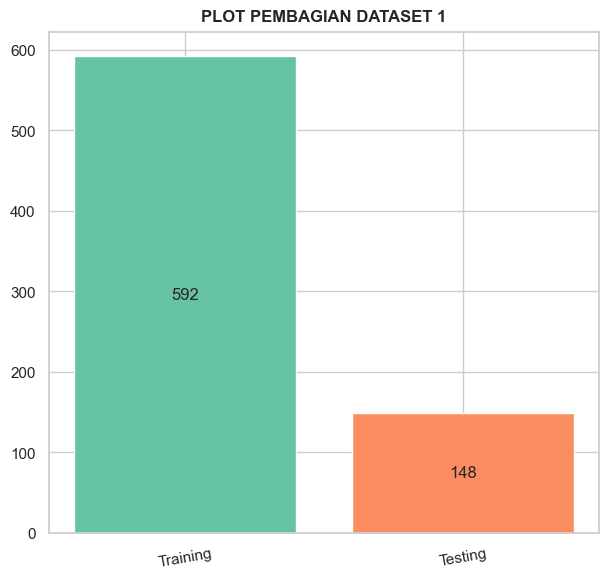

In [8]:
%matplotlib inline
# Plot Label
x_list = []
y_list = []
title_list = []
for i, (sumber, item) in enumerate(dict_split.items()):
    num_train = len(item['X_train'])
    num_test = len(item['X_test'])

    label_texts = ["Training", "Testing"]
    label_values = [num_train, num_test]
    
    title_list.extend([f"PLOT PEMBAGIAN DATASET {i + 1}"])
    x_list.append(label_texts)
    y_list.append(label_values)
myplot.bar_plot_grid(x_list=x_list, y_list=y_list, title_list=title_list)

# 4. KLASIFIKASI
___

## KLASIFIKASI MACHINE LEARNING
___

### Training Model

#### Fungsi Training

In [9]:
# =====================================================
# Fungsi: melakukan training model
# =====================================================
def training_model_ml(X, y, model_name, save_model=False, params=None):
    if params is None:
        params = {}

    model_name = model_name.lower()

    # Mapping model singkat → tuple (butuh_scaling, constructor)
    model_map = {
        "svm": (True, SVC),
        "svc": (True, SVC),
        "knn": (True, KNeighborsClassifier),
        "mlp": (True, MLPClassifier),
        "neural": (True, MLPClassifier),
        "logreg": (True, LogisticRegression),
        "logisticregression": (True, LogisticRegression),
        "rf": (False, RandomForestClassifier),
        "randomforest": (False, RandomForestClassifier),
    }

    if model_name not in model_map:
        raise ValueError(f"Model '{model_name}' tidak dikenali!")

    use_scaler, ModelClass = model_map[model_name]

    # Buat pipeline jika perlu scaling
    if use_scaler:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", ModelClass(**params))
        ])
    else:
        model = ModelClass(**params)

    model = clone(model)
    model.fit(X, y)

    # Save model
    if save_model:
        with open(save_model, "wb") as f:
            pickle.dump(model, f)

    return model

#### Proses Training

In [10]:
# Nama Model : Parameter
models_ml = {
    "SVM": {'probability': True, 'random_state':42},
    "KNN": {},
    "RandomForest": {'random_state':42},
    "LogisticRegression": {'random_state':42},
    "MLP": {'random_state':42, 'max_iter':2000}
}

In [11]:
# Mulai timer
timer = mytimer.loop_timer()
next(timer)

total_iterasi = len(models_ml) * len(dict_split)
current_iter = 0
time_list = []

# Proses Training Semua Model
for model_name, params in models_ml.items():
    for sumber, dsplit in dict_split.items():
        # Hitung waktu satu iterasi (start)
        dt = timer.send("tick")
        if dt is not None:
            time_list.append(dt)
        # update posisi iterasi
        current_iter += 1

        # =================================================================================

        # Lokasi file model yang akan disimpan
        save_model = os.path.join(PATH_FOLDER['path_model_b'], sumber, f"{model_name}.pkl")

        # Ambil dataset train
        X_train = np.array(dsplit['X_train'])
        y_train = np.array(dsplit['y_train'])

        print(f"\n[{current_iter}/{total_iterasi}] Proses Training Model\t: {model_name}")
        print(f"      Sumber Dataset\t\t: {sumber}")

        # Proses Training Model ML
        model = training_model_ml(X=X_train, 
                                  y=y_train,
                                  model_name=model_name, 
                                  save_model=save_model,
                                  params=params)
        
        # Menghitung Akurasi
        y_pred = model.predict(X_train)
        acc = accuracy_score(y_train, y_pred)

        print(f"      Akurasi\t\t\t: {acc}")
        print(f"      Model disimpan\t\t: {save_model}")
        # =================================================================================
        print(f"      Waktu iterasi\t\t: {dt:.4f} detik")

# Akhiri timer (ambil total waktu)
info = timer.send("done")

# Tambahkan rata-rata waktu
info["avg_time"] = sum(time_list) / len(time_list)

print("\n======================")
print("       RINGKASAN     ")
print("======================")
print(f"Total iterasi : {total_iterasi}")
print(f"Total waktu   : {info['total_time']:.4f} detik")
print(f"Rata-rata per iterasi : {info['avg_time']:.4f} detik")


[1/5] Proses Training Model	: SVM
      Sumber Dataset		: dataset_1
      Akurasi			: 0.9425675675675675
      Model disimpan		: Model_B\dataset_1\SVM.pkl
      Waktu iterasi		: 0.0000 detik

[2/5] Proses Training Model	: KNN
      Sumber Dataset		: dataset_1
      Akurasi			: 0.8952702702702703
      Model disimpan		: Model_B\dataset_1\KNN.pkl
      Waktu iterasi		: 0.3192 detik

[3/5] Proses Training Model	: RandomForest
      Sumber Dataset		: dataset_1
      Akurasi			: 0.9983108108108109
      Model disimpan		: Model_B\dataset_1\RandomForest.pkl
      Waktu iterasi		: 2.6270 detik

[4/5] Proses Training Model	: LogisticRegression
      Sumber Dataset		: dataset_1
      Akurasi			: 0.9662162162162162
      Model disimpan		: Model_B\dataset_1\LogisticRegression.pkl
      Waktu iterasi		: 0.5715 detik

[5/5] Proses Training Model	: MLP
      Sumber Dataset		: dataset_1
      Akurasi			: 0.9983108108108109
      Model disimpan		: Model_B\dataset_1\MLP.pkl
      Waktu iterasi		: 0.086

## KLASIFIKASI DEEP LEARNING
___

### Mengubah format menjadi Tensor

In [17]:
def convert_dataframe_to_tensor(df, model_type="efficientnet_b0", base_path="", image_size=(224, 224), batch_size=16):
    model_type_low = model_type.lower()
    # Lokasi File
    file_paths = df["LOKASI_GAMBAR"].apply(lambda x: os.path.join(base_path, x)).tolist()
    # Label
    labels = df["LABEL"].astype("float32").tolist()

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    # Pilih preprocess_input sesuai model
    if model_type_low.startswith("efficientnet"):
        from tensorflow.keras.applications.efficientnet import preprocess_input
    elif model_type_low.startswith("resnet"):
        from tensorflow.keras.applications.resnet import preprocess_input
    elif model_type_low.startswith("mobilenet_v3"):
        from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
    else:
        raise ValueError(f"{model_type} tidak dikenal")

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_png(image, channels=3)
        image = tf.image.resize(image, image_size)
        image = preprocess_input(image)
        return image, label

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

### Model

In [18]:
def build_modern_cnn(model_name="mobilenet_v3", 
                    image_size = (224, 224),
                    num_classes=1,
                    train_base=False):

    input_shape = (*image_size, 3)

    model_key = model_name.lower()

    # ===== Pilih Backbone Ringkas =====
    backbones = {
        "efficientnet_b0": tf.keras.applications.EfficientNetB0,
        "resnet50": tf.keras.applications.ResNet50,
        "mobilenet_v3": tf.keras.applications.MobileNetV3Small,
    }

    if model_key == "efficientnet_b0":
        # Download Manual Weights
        path = tf.keras.utils.get_file("efficientnetb0_notop.h5", origin="https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5")
        # Build model tanpa weights
        base_model = backbones[model_key](
            include_top=False,
            weights=None,
            input_shape=input_shape
        )

        # Load weights manual
        base_model.load_weights(path)

    elif model_key in ['resnet50', 'mobilenet_v3']:
        # Build model
        base_model = backbones[model_key](
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    else:
        raise ValueError(f"Backbone tidak dikenal: {model_name}")


    # Freeze / Unfreeze backbone
    base_model.trainable = train_base

    # BANGUN MODEL
    # Input Layer
    inputs = tf.keras.layers.Input(shape=input_shape)
    # Backbone CNN tanpa train ulang
    x = base_model(inputs, training=train_base) 
    # Pooling: menonjolkan fitur paling kuat
    x = tf.keras.layers.GlobalMaxPool2D()(x)   
    # dropout untuk mengurangi overfitting         
    x = tf.keras.layers.Dropout(0.3)(x)                         

    # OUTPUT: Binary atau Multiclass
    if num_classes == 1:
        # Sigmoid untuk klasifikasi binary (0/1)
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
        loss = "binary_crossentropy"
    else:
        # Softmax untuk multi-class
        outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
        loss = "categorical_crossentropy"

    # Bangun model
    model = tf.keras.models.Model(inputs, outputs)

    # Kompilasi model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=loss,  
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.Precision(name="precision"),
        ]
    )

    return model

### Callback

In [19]:
class TestMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, test_ds, best_model_path, monitor="val_auc", mode="max"):
        super().__init__()
        self.test_ds = test_ds
        self.best_model_path = best_model_path
        self.monitor = monitor
        self.mode = mode

        self.best = -np.inf if mode == "max" else np.inf
        self.best_epoch = None
        self.history = []

    def on_epoch_begin(self, epoch, logs=None):
        print("_" * 100)
        print(f"\n Epoch {epoch + 1} Mulai")
        print("_" * 100)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)

        if current is None:
            return

        improved = (
            current > self.best if self.mode == "max"
            else current < self.best
        )

        if not improved:
            return
        
        # Update best
        self.best = current
        self.best_epoch = epoch + 1

        print(f"\nModel Terbaik → Evaluasi pada TEST set")

        results = self.model.evaluate(
            self.test_ds,
            verbose=1,
            return_dict=True
        )

        self.history.append({
            "epoch": self.best_epoch,
            **results
        })

        print(f"\nModel Terbaik → Evaluasi pada VAL set")

    def on_train_end(self, logs=None):
        print("_" * 50)
        print("\nTraining selesai.")
        print(f"\nHasil Epoch Terbaik {self.best_epoch} → Evaluasi Hasil Akhir Terbaik pada TEST set")

        # Load model terbaik dari ModelCheckpoint
        best_model = tf.keras.models.load_model(self.best_model_path)

        results = best_model.evaluate(
            self.test_ds,
            verbose=1,
            return_dict=True
        )
        
        print("_" * 50)


def build_callbacks(model_path, test_ds):
    callbacks = [

        # Hentikan training bila val_loss tidak membaik
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",       # metrik yang dipantau
            patience=6,              # berhenti jika 6 epoch tidak membaik
            restore_best_weights=True,
            verbose=1
        ),

        # Simpan model terbaik berdasarkan val_loss
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,     # hanya model terbaik yang disimpan
            save_weights_only=False,
            verbose=1
        ),

        # Uji otomatis pada test set
        TestMetricsCallback(
            test_ds,
            best_model_path=model_path,
            monitor="val_loss",
            mode="min"
        )
    ]

    return callbacks

### Proses Training

In [20]:
models_dl = ["EfficientNet_B0", "ResNet50", "MobileNet_v3"]

# Mulai timer
timer = mytimer.loop_timer()
next(timer)

total_iterasi = len(models_dl) * len(dict_split)
current_iter = 0
time_list = []

# Proses Training Semua Model
for model_name in models_dl:
    for sumber, dsplit in dict_split.items():
        current_iter += 1
        # =================================================================================
        print("\n")
        print("=" * 120)
        print("=" * 120)
        print(f"[{current_iter}/{total_iterasi}] Proses Training Model\t: {model_name}")
        print(f"      Sumber Dataset\t\t: {sumber}")
        
        # Lokasi File Model Baru
        save_model = os.path.join(
            PATH_FOLDER['path_model_b'], sumber, f"{model_name}.keras"
        )
        save_model_history = os.path.join(
            PATH_FOLDER['path_model_b'], sumber, f"history_{model_name}.pkl"
        )

        if os.path.exists(save_model):
            os.remove(save_model)
        if os.path.exists(save_model_history):
            os.remove(save_model_history)

        # Mengambil dataset hasil pembagian didalam dict_split
        idx_train = dsplit['X_train'].index.tolist()
        idx_test = dsplit['X_test'].index.tolist()

        df_train, df_val = train_test_split(
            df.iloc[idx_train],
            train_size=0.8,
            random_state=42,
            stratify=df.iloc[idx_train]["LABEL"]
        )
        df_test = df.iloc[idx_test]

        # Ubah data menjadi tensor
        # Data Training
        train_ds = convert_dataframe_to_tensor(
            df=df_train,
            base_path=PATH_FOLDER['dataset_extract_b'],
            image_size=IMAGE_SIZE
        )
        
        # Data Validation
        val_ds = convert_dataframe_to_tensor(
            df=df_val,
            base_path=PATH_FOLDER['dataset_extract_b'],
            image_size=IMAGE_SIZE
        )
        # Data Testing
        test_ds = convert_dataframe_to_tensor(
            df=df_test,
            base_path=PATH_FOLDER['dataset_extract_b'],
            image_size=IMAGE_SIZE
        )

        print(f"      Data Training\t\t: {len(df_train)}")
        print(f"      Data Validation\t\t: {len(df_val)}")
        print(f"      Data Testing\t\t: {len(df_test)}")
        print("=" * 120)
        print("=" * 120)
        # Model
        model = build_modern_cnn(model_name=model_name, image_size=IMAGE_SIZE)

        # Summary
        print(model.summary())

        # Callback
        callbacks = build_callbacks(
            model_path=save_model, 
            test_ds=test_ds
        )

        # Proses Training Model
        history = model.fit(
            train_ds, 
            validation_data=val_ds,
            epochs=100, 
            callbacks=callbacks,
            verbose=1
        )
        
        # Simpan history training CNN
        history_dict = history.history.copy()

        # Tambahkan evaluasi TEST (hanya saat model terbaik)
        history_dict['test_history'] = callbacks[-1].history
        history_dict['best_epoch'] = callbacks[-1].best_epoch

        # Simpan File
        with open(save_model_history, 'wb') as f:
            pickle.dump(history_dict, f)
        
        # =================================================
        # Hitung waktu iterasi
        # =================================================
        dt = timer.send("tick")
        if dt is not None:
            time_list.append(dt)
        print(f"\n Waktu iterasi: {mytimer.format_time(dt)}")
        print("_" * 50)

    

# =====================================================
# Akhiri timer dan hitung rata-rata waktu
# =====================================================
info = timer.send("done")
info["avg_time"] = sum(time_list) / len(time_list)

# =====================================================
# Tampilkan Ringkasan
# =====================================================
print("\n======================")
print("       RINGKASAN     ")
print("======================")
print(f"Total iterasi            : {total_iterasi}")
print(f"Total waktu              : {mytimer.format_time(info['total_time'])}")
print(f"Rata-rata waktu/iterasi  : {mytimer.format_time(info['avg_time'])}")



[1/3] Proses Training Model	: EfficientNet_B0
      Sumber Dataset		: dataset_1
      Data Training		: 473
      Data Validation		: 119
      Data Testing		: 148


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (None, 576)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

None
____________________________________________________________________________________________________

 Epoch 1 Mulai
____________________________________________________________________________________________________
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5279 - auc: 0.5240 - loss: 2.6234 - precision: 0.5325 - sensitivity: 0.6351
Epoch 1: val_loss improved from None to 0.74624, saving model to Model_B\dataset_1\MobileNet_v3.keras

Epoch 1: finished saving model to Model_B\dataset_1\MobileNet_v3.keras

Model Terbaik → Evaluasi pada TEST set
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.6757 - auc: 0.7154 - loss: 0.7292 - precision: 0.6327 - sensitivity: 0.8378

Model Terbaik → Evaluasi pada VAL set
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 376ms/step - accuracy: 0.5349 - auc: 0.5472 - loss: 2.0382 - precision: 0.5353 - sensitivity: 0.5443 - val_accuracy: 0.6639 - val_auc: 0.7295 - val_loss: 0.7462 - val_precision: 0.6067 - val_sensitivity: 0.9153
_________

# 5. EVALUASI MODEL
___

### Fungsi Metrics Utilites

In [21]:
# ============================================================
# Fungsi Menghitung Specificity Score
# TN / (TN + FP)
# ============================================================
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


# ============================================================
# Fungsi Menghitung Seluruh Metrik Klasifikasi Utam
# Accuracy, Recall, Specificity, Precision, F1-Score, dan AUC
# ============================================================
def compute_classification_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None:
        metrics["AUC"] = roc_auc_score(y_true, y_prob)

    return {
        "data": {
            "y_true": y_true.tolist(),
            "y_pred": y_pred.tolist(),
            "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
            "class_names": np.unique(y_true).tolist(),
        },
        "metrics": metrics,
    }

### Core Model Evaluation (ML/DL)

In [22]:
# ============================================================
# Fungsi Evaluasi performa model (ML atau DL), termasuk:
# - prediksi
# - metrik klasifikasi
# - waktu komputasi
# - penggunaan memori
# ============================================================
def evaluate_model_performance(model, X=None, y=None, test_dataset=None):
    start_time = time.perf_counter()
    tracemalloc.start()

    y_true, y_pred, y_prob = [], [], None

    # ===================== DEEP LEARNING =====================
    if test_dataset is not None:
        y_prob = []

        for images, labels in test_dataset:
            probs = model.predict(images, verbose=0).reshape(-1)
            preds = (probs >= 0.5).astype(int)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        y_prob = np.array(y_prob)

    # ===================== MACHINE LEARNING ==================
    else:
        y_true = np.asarray(y)
        y_pred = model.predict(X)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X)[:, 1]

    # ===================== RESOURCE USAGE ====================
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    elapsed_time = time.perf_counter() - start_time

    results = compute_classification_metrics(y_true, y_pred, y_prob)
    results["resources"] = {
        "computational_time_sec": elapsed_time,
        "memory_footprint_MB": current_mem / (1024 ** 2),
        "memory_peak_MB": peak_mem / (1024 ** 2),
    }

    return results


### Stability Analysis (ML & DL)

In [23]:
# ============================================================
# Fungsi Menambahkan Gaussian noise ke image dataset (Deep Learning).
# ============================================================
def add_gaussian_noise_to_dataset(dataset, stddev):
    def _apply_noise(images, labels):
        noise = tf.random.normal(
            shape=tf.shape(images),
            mean=0.0,
            stddev=stddev,
            dtype=images.dtype
        )
        images_noisy = tf.clip_by_value(images + noise, 0.0, 1.0)
        return images_noisy, labels

    return dataset.map(_apply_noise, num_parallel_calls=tf.data.AUTOTUNE)


# ============================================================
# Fungsi Menghitung Stability Index model terhadap variasi Gaussian noise (ML/DL).
# ============================================================
def evaluate_stability_index(model, X=None, y=None, test_dataset=None,
                             noise_levels=(0.01, 0.03, 0.05), threshold=0.5, random_state=42,):
  
    rng = np.random.default_rng(random_state)
    scores = []

    for noise_std in noise_levels:

        # ===================== DEEP LEARNING =====================
        if test_dataset is not None:
            noisy_dataset = add_gaussian_noise_to_dataset(test_dataset, noise_std)
            y_true, y_pred = [], []

            for images, labels in noisy_dataset:
                probs = model.predict(images, verbose=0).reshape(-1)
                preds = (probs >= threshold).astype(int)
                y_true.extend(labels.numpy())
                y_pred.extend(preds)

            y_true = np.array(y_true)
            y_pred = np.array(y_pred)

        # ===================== MACHINE LEARNING ==================
        else:
            noise = rng.normal(0.0, noise_std, X.shape)
            X_noisy = X + noise
            y_true = np.asarray(y)
            y_pred = model.predict(X_noisy)

        score = accuracy_score(y_true, y_pred)
        scores.append(score)

    scores = np.array(scores)
    stability_index = 1.0 - (scores.std() / (scores.mean() + 1e-8))

    return {
        "noise_levels": list(noise_levels),
        "scores": scores.tolist(),
        "stability_index": float(stability_index),
        "metric_used": "Accuracy",
    }


### Pipeline Evaluation (Multi-Model)

In [24]:
# ============================================================
# Pipeline evaluasi banyak model (ML atau DL).
# ============================================================
def run_evaluation_pipeline(model_names, model_dir, dataset_name,
                            X=None, y=None, test_dataset=None,
                            current_iter=0, total_iter=1, elapsed_dt=0.0, results_store=None):
    if results_store is None:
        results_store = {}

    is_dl = test_dataset is not None
    # Tipe model berdasarkan extension file
    model_type = "Deep Learning" if is_dl else "Machine Learning"
    model_ext = ".keras" if is_dl else ".pkl"

    print(f"\n--- Evaluasi {model_type} | Dataset: {dataset_name} ---")
    # 
    for model_name in model_names:
        current_iter += 1
        # Lokasi Model
        model_path = os.path.join(model_dir, f"{model_name}{model_ext}")
        # Lokasi History Model
        history_path = os.path.join(model_dir, f"history_{model_name}.pkl")

        if not os.path.exists(model_path):
            print(f"[{current_iter}/{total_iter}] {model_name} → SKIP")
            continue

        print(f"[{current_iter}/{total_iter}] {model_name} → Evaluating")

        # Load model
        model = (tf.keras.models.load_model(model_path) if is_dl else pickle.load(open(model_path, "rb")))

        # Core evaluation
        metrics = evaluate_model_performance(model, X=X, y=y, test_dataset=test_dataset)

        # Stability analysis
        metrics["stability"] = evaluate_stability_index(model, X=X, y=y, test_dataset=test_dataset)

        # Model size
        metrics["resources"]["model_size_MB"] = (os.path.getsize(model_path) / (1024 ** 2))

        # Training history (DL)
        if os.path.exists(history_path):
            with open(history_path, "rb") as f:
                metrics["history_train"] = pickle.load(f)
        else:
            metrics["history_train"] = None

        # example = {dataset_1_SVM: 
        results_store[f"{dataset_name}_{model_name}"] = metrics

        print(f"\tAccuracy : {metrics['metrics']['Accuracy']:.4f}")
        print(f"\tTime     : {metrics['resources']['computational_time_sec']:.4f} s")

    return current_iter, results_store

## Proses Evaluasi Model

In [25]:
models_ml = ["SVM", "KNN", "RandomForest", "LogisticRegression", "MLP"]
models_dl = ["EfficientNet_B0", "ResNet50", "MobileNet_v3"]

results = {}
current_iter = 0

for dataset_name, split in dict_split.items():
    X_test = np.array(split["X_test"])
    y_test = np.array(split["y_test"])

    test_ds = convert_dataframe_to_tensor(
        df=df.iloc[split["X_test"].index.tolist()],
        base_path=PATH_FOLDER["dataset_extract_b"],
        image_size=IMAGE_SIZE,
    )

    model_path = os.path.join(PATH_FOLDER["path_model_b"], dataset_name)

    # ============== Machine Learning ==============
    current_iter, results = run_evaluation_pipeline(
        model_names=models_ml,
        model_dir=model_path,
        dataset_name=dataset_name,
        X=X_test,
        y=y_test,
        current_iter=current_iter,
        total_iter=len(models_ml) + len(models_dl),
        results_store=results,
    )

    # ============== Deep Learning ==============
    current_iter, results = run_evaluation_pipeline(
        model_names=models_dl,
        model_dir=model_path,
        dataset_name=dataset_name,
        test_dataset=test_ds,
        current_iter=current_iter,
        total_iter=len(models_ml) + len(models_dl),
        results_store=results,
    )



--- Evaluasi Machine Learning | Dataset: dataset_1 ---
[1/8] SVM → Evaluating
	Accuracy : 0.8311
	Time     : 0.0368 s
[2/8] KNN → Evaluating
	Accuracy : 0.8243
	Time     : 0.1187 s
[3/8] RandomForest → Evaluating
	Accuracy : 0.8378
	Time     : 0.1068 s
[4/8] LogisticRegression → Evaluating
	Accuracy : 0.7973
	Time     : 0.0044 s
[5/8] MLP → Evaluating
	Accuracy : 0.8446
	Time     : 0.0040 s

--- Evaluasi Deep Learning | Dataset: dataset_1 ---
[6/8] EfficientNet_B0 → Evaluating
	Accuracy : 0.9054
	Time     : 31.1862 s
[7/8] ResNet50 → Evaluating
	Accuracy : 0.8784
	Time     : 25.3580 s
[8/8] MobileNet_v3 → Evaluating
	Accuracy : 0.8851
	Time     : 15.4464 s


In [26]:
# Simpan hasil akhir ke json
with open('skenario_B_final.json', "w") as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

## Visualisasi

In [27]:
with open('skenario_B_final.json', 'r') as f:
    results = json.load(f)

In [28]:
%matplotlib inline
# ============================================================
# Fungsi Visualisasi Evaluasi Model
# ============================================================
def visualisasi(dict_results, list_sumber, display):
    for sumber in list_sumber:

        # Struktur penampung data
        history_cnn  = {'history_list': [], 'titles': []}
        conf_matrix  = {'conf_matrices': [], 'titles': [], 'class_names': None}
        eval_metrics = {'metrics_list': [], 'titles': []}
        comput_time = {'results': [], 'titles': []}
        rss_usage = {'results': [], 'titles': []}
        stability_result = {'results':[], 'titles':[]}

        # Filter semua model berdasarkan sumber
        model_keys = [k for k in dict_results if k.startswith(sumber)]

        for key in model_keys:
            result = dict_results[key]
            model_name = key.split(f"{sumber}_", 1)[1]

            # -------------------------------------------------------
            # HISTORY TRAINING CNN
            # -------------------------------------------------------
            history_dict = result.get("history_train")
            if history_dict:
                history_cnn['history_list'].append(dict(history_dict))
                history_cnn['titles'].append(f"History Training {model_name} - {sumber}")

            # -------------------------------------------------------
            # CONFUSION MATRIX
            # -------------------------------------------------------
            data_block = result.get("data")
            if data_block:
                cm          = data_block.get("confusion_matrix")
                class_names = data_block.get("class_names")

                if cm is not None:
                    conf_matrix['conf_matrices'].append(cm)
                    conf_matrix['titles'].append(model_name)
                    conf_matrix['class_names'] = class_names

            # -------------------------------------------------------
            # EVALUASI METRIK MODEL
            # -------------------------------------------------------
            metrics = result.get("metrics")
            if metrics:
                eval_metrics['metrics_list'].append(dict(metrics))
                eval_metrics['titles'].append(model_name)

            resources = result.get("resources")
            if resources:
                # -------------------------------------------------------
                # Computational Time
                # -------------------------------------------------------
                comput_time['results'].append(resources)
                comput_time['titles'].append(model_name)
                # -------------------------------------------------------
                # Resource Usage Comparison
                # -------------------------------------------------------
                rss_usage['results'].append(resources)
                rss_usage['titles'].append(model_name)
            # -------------------------------------------------------
            # Stability Index
            # -------------------------------------------------------
            stability = result.get("stability")
            if stability:
                stability_result['results'].append(stability) 
                stability_result['titles'].append(model_name)


        # =======================================================
        # TAMPILKAN SEMUA VISUALISASI SESUAI REQUEST
        # =======================================================
        if "history_cnn" in display:
            myplot.plot_history_cnn_grid(**history_cnn, save_as=os.path.join(PATH_FOLDER['path_plot'], "history_cnn_B.png"))

        if "confusion_matrix" in display:
            myplot.plot_confusion_matrices_grid(
                **conf_matrix,
                main_title=f"Confusion Matrix | {sumber}",
                max_cols=max(1, len(conf_matrix['conf_matrices']) // 2),
                save_as=os.path.join(PATH_FOLDER['path_plot'], "confusion_matrix_B.png")
            )

        if "evaluate_models" in display:
            myplot.plot_classification_metrics_bar(
                **eval_metrics,
                main_title=f"Model Evaluation Metrics | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "evaluate_models_B.png")
            )
            
        if "computational_time" in display:
            myplot.plot_computational_time(
                **comput_time,
                main_title=f"Computational Time | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "computational_time_B.png")
            )

        if 'resource_usage' in display:
            myplot.plot_resource_usage(
                **rss_usage,
                main_title=f"Resource Usage Comparison | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "resource_usage_B.png")
            )
            
        if 'stability_index' in display:
            myplot.plot_stability_index(
                **stability_result,
                main_title=f"Stability Index Comparison | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "stability_index_B.png")
            )

### Visualisasi History Training CNN

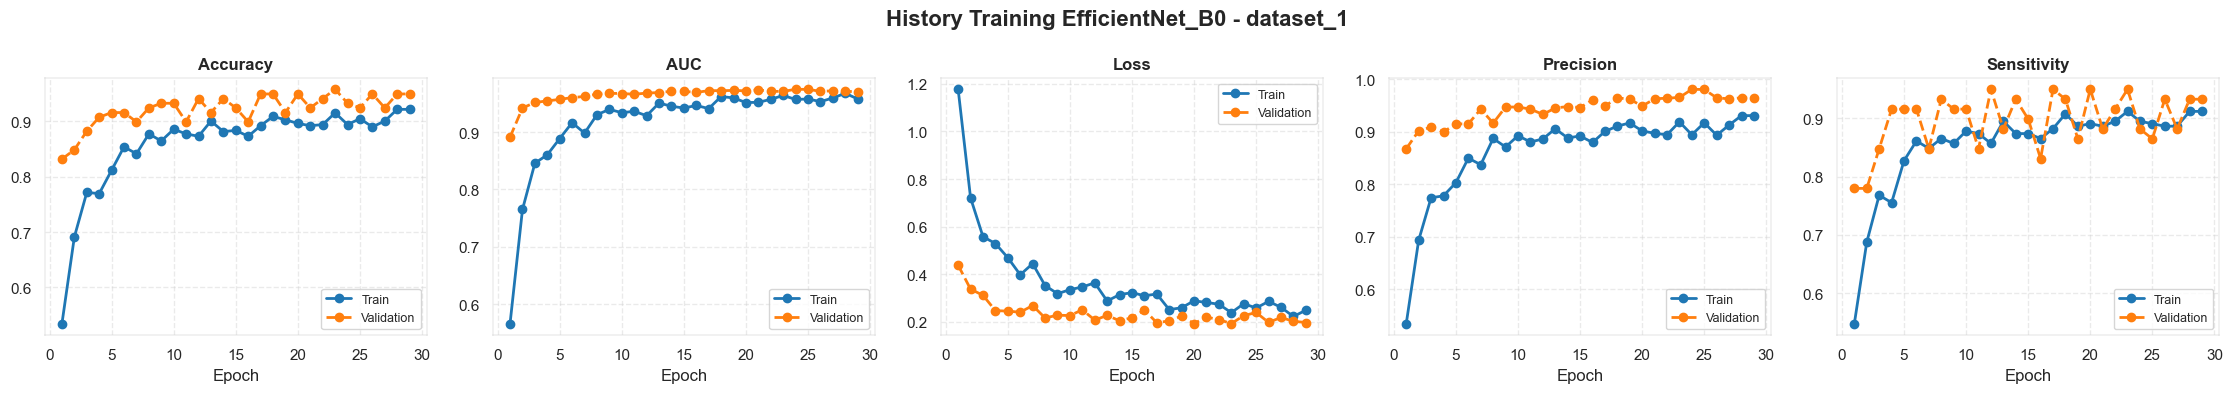

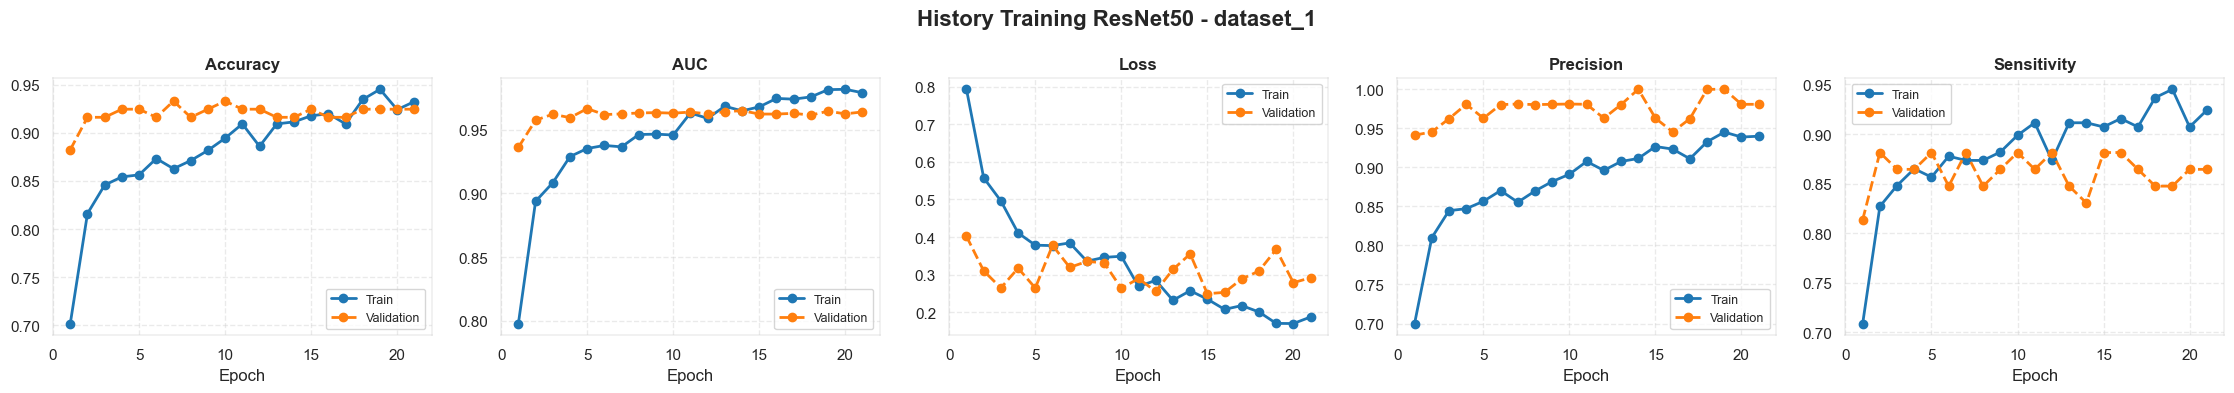

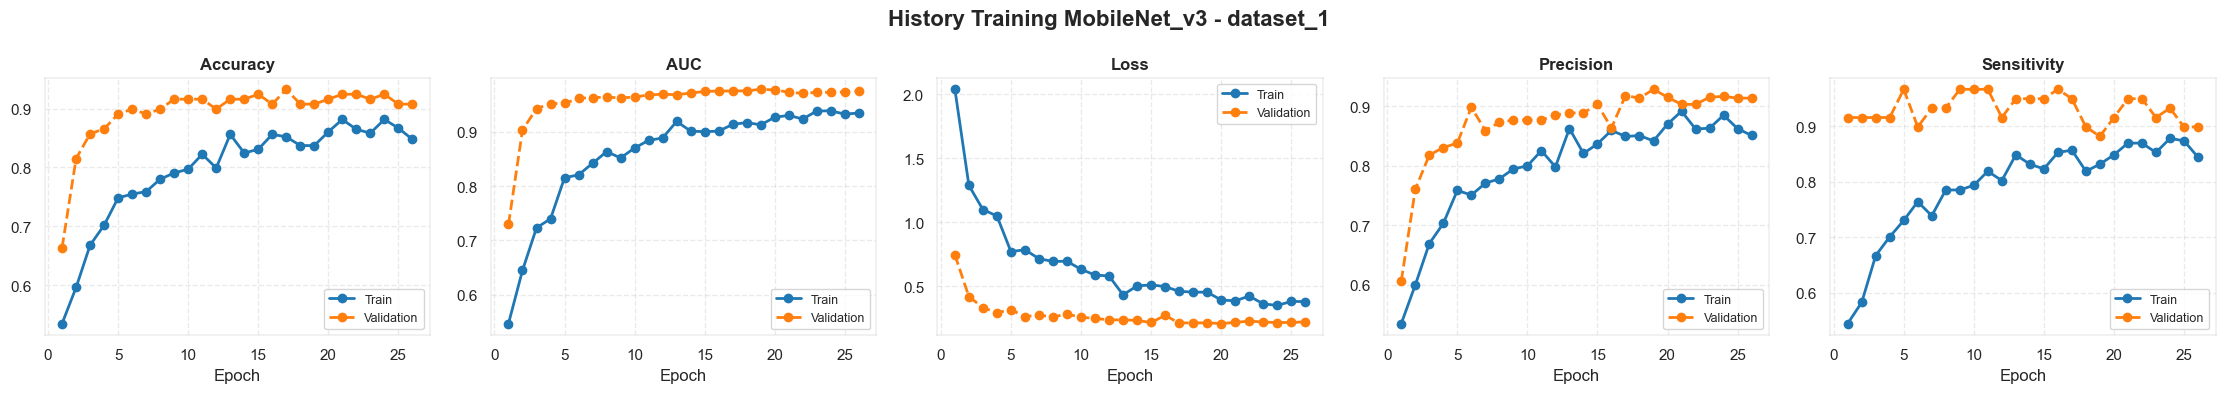

In [29]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['history_cnn'])

### Visualisasi Confusion Matrix

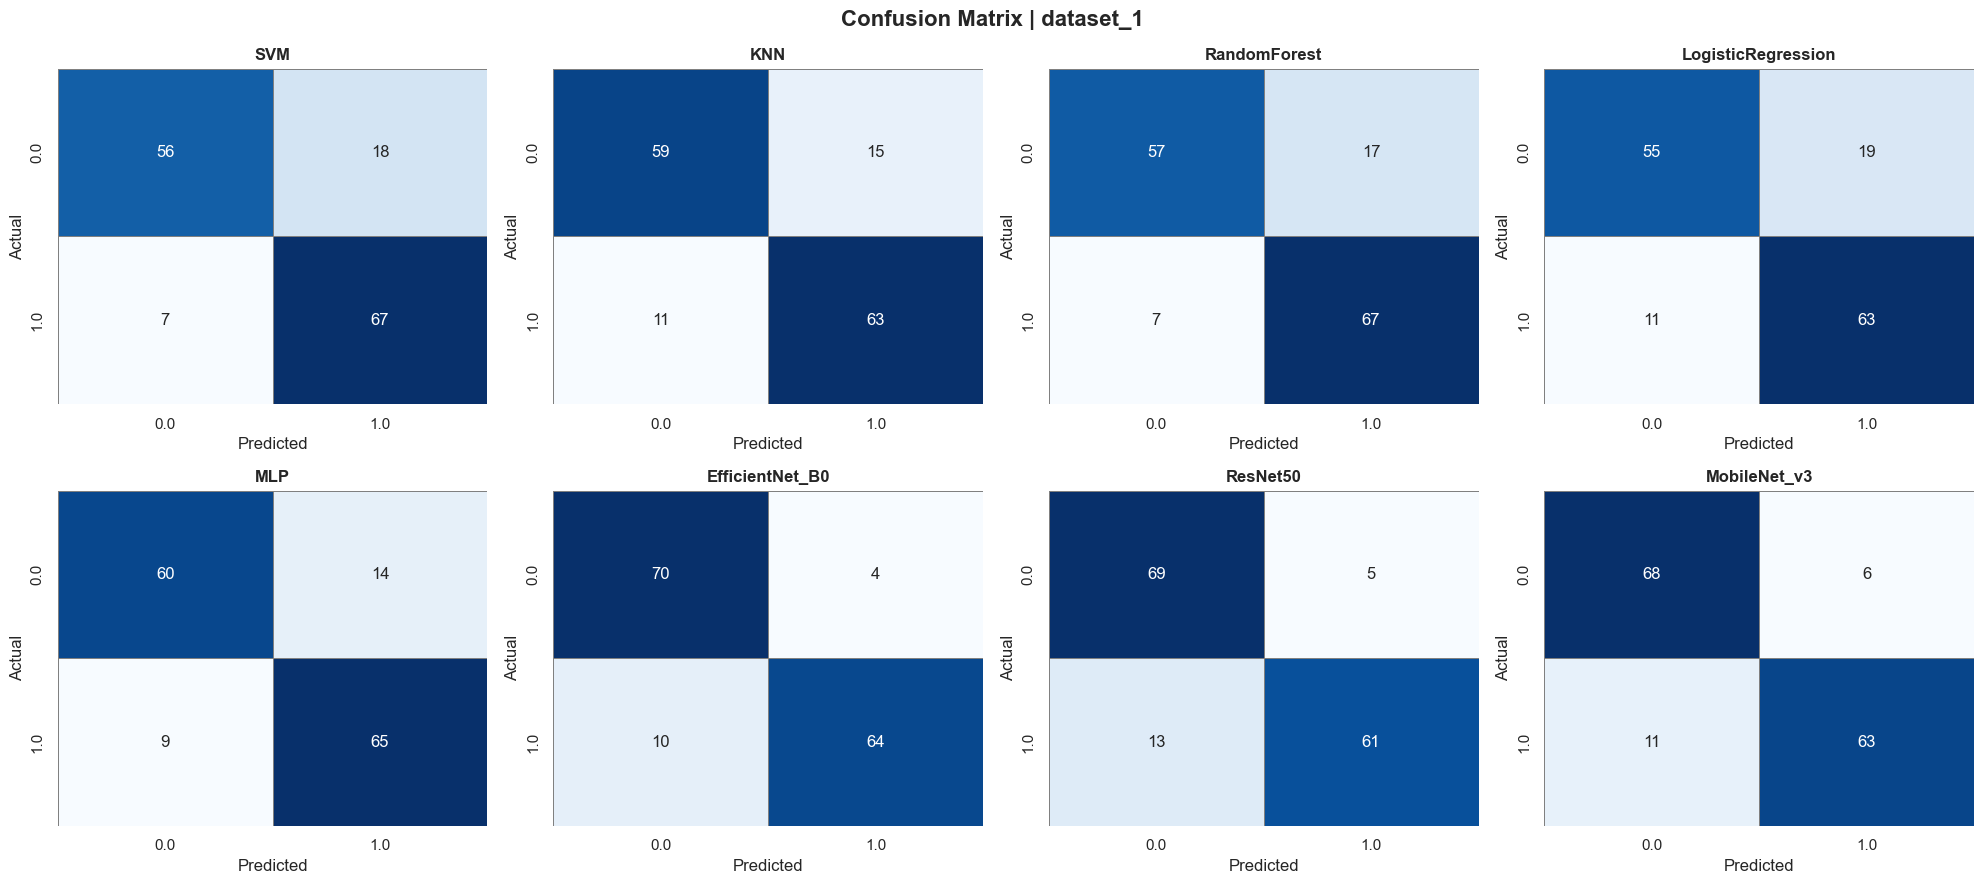

In [30]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['confusion_matrix'])

### Visualisasi Evaluasi Model

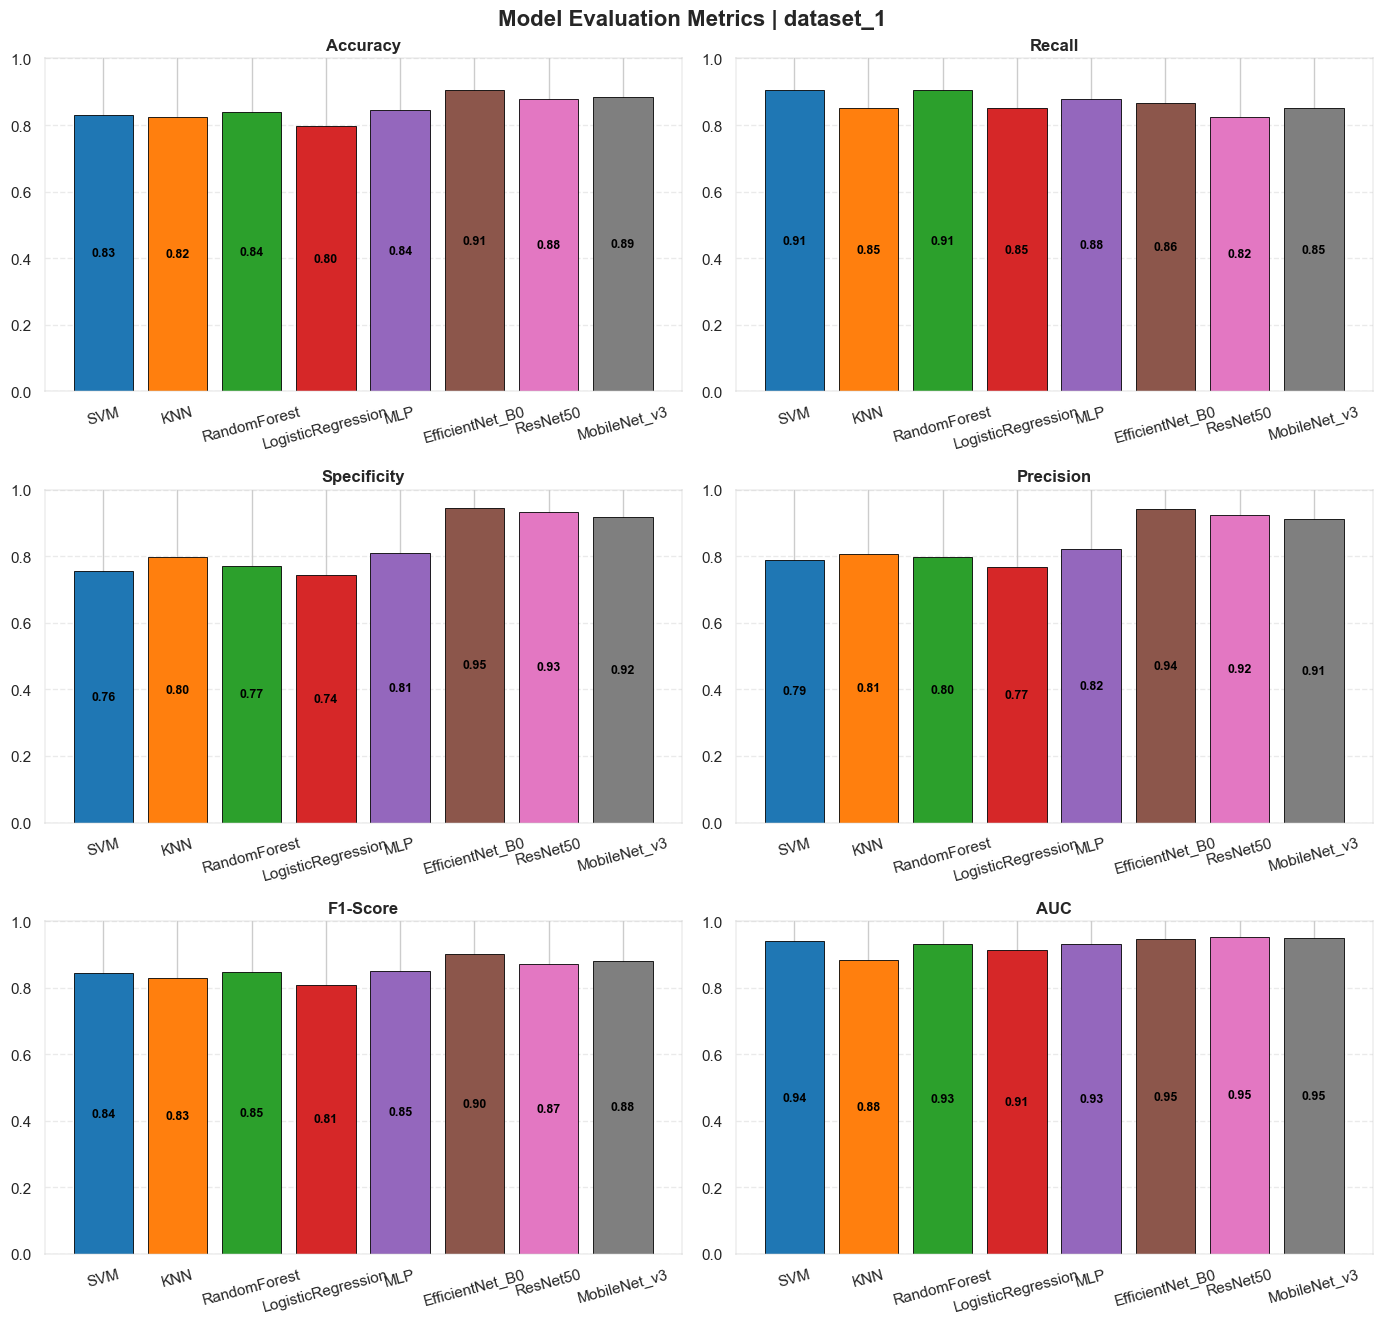

In [31]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['evaluate_models'])

### Visualisasi Computational Time

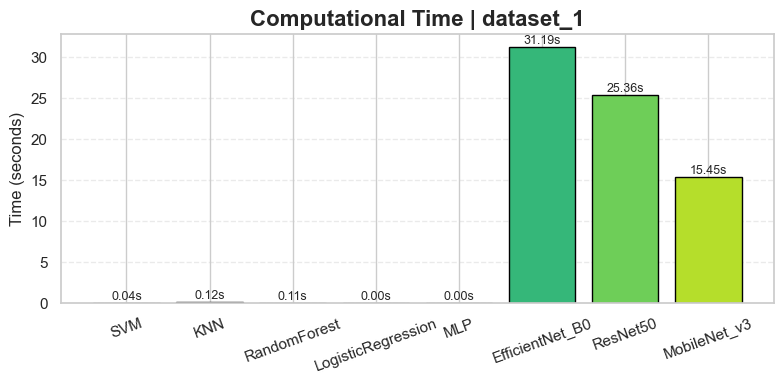

In [32]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['computational_time'])

### Visualisasi Resource Usage

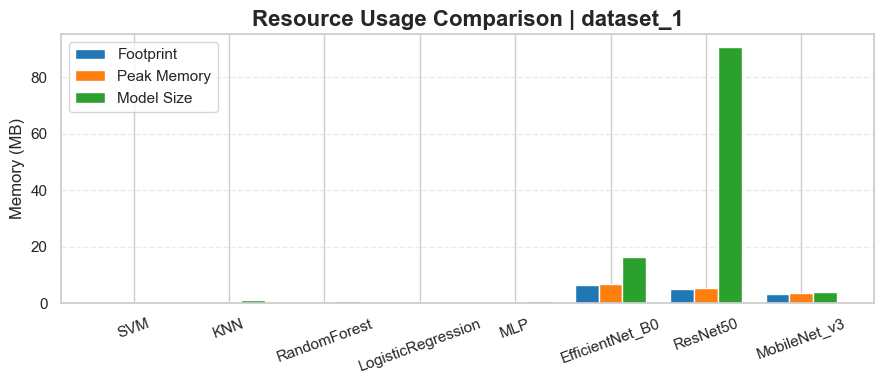

In [33]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['resource_usage'])

### Visualisasi Stability Index

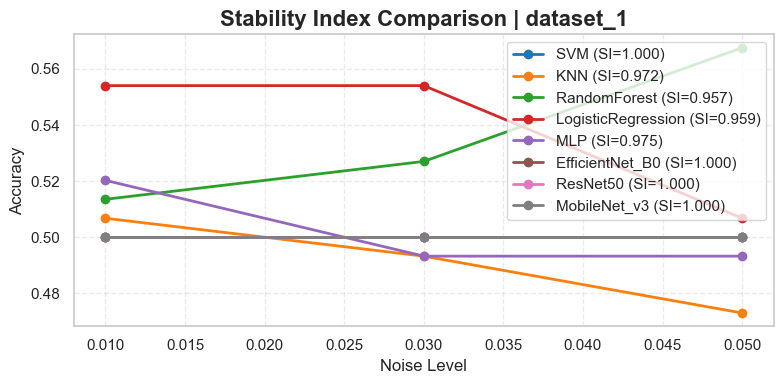

In [34]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['stability_index'])